# 🎓 Student Performance Predictor
## Task 1: Data Loading and Exploratory Data Analysis (EDA)

### Objective


The objective of this notebook is to load a student performance dataset, explore its structure, identify any data quality issues, 
visualize relationships between variables, and generate insights before building a machine learning model.




In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Better plot style
plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("Libraries imported successfully.")


Libraries imported successfully.


In [5]:
# ==========================================
# Create Student Dataset
# ==========================================

student_data = {
    "Hours_Studied":[1,2,3,4,5,6,7,8,9,10,2.5,3.5,4.5,5.5,6.5,7.5,8.5],
    "Attendance":[60,65,70,72,75,80,82,85,90,95,68,71,74,78,83,87,92],
    "Previous_Score":[40,42,45,48,55,58,63,68,72,80,44,47,53,60,66,70,76],
    "Sleep_Hours":[5,6,6,7,7,8,8,8,9,9,6,6,7,7,8,8,9],
    "Exam_Score":[35,42,47,53,60,66,73,80,87,95,45,50,57,64,70,78,90]
}

# Convert dictionary into DataFrame
df = pd.DataFrame(student_data)

print("Dataset created successfully.")

Dataset created successfully.


In [6]:
# ==========================================
# Display First and Last Records
# ==========================================

print("First Five Records")
display(df.head())

print("Last Five Records")
display(df.tail())

First Five Records


,Hours_Studied,Attendance,Previous_Score,Sleep_Hours,Exam_Score
0,1.0,60,40,5,35
1,2.0,65,42,6,42
2,3.0,70,45,6,47
3,4.0,72,48,7,53
4,5.0,75,55,7,60


Last Five Records


,Hours_Studied,Attendance,Previous_Score,Sleep_Hours,Exam_Score
12,4.5,74,53,7,57
13,5.5,78,60,7,64
14,6.5,83,66,8,70
15,7.5,87,70,8,78
16,8.5,92,76,9,90


In [7]:
# ==========================================
# Basic Information About Dataset
# ==========================================

print("Dataset Shape:", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

print("\nDataset Information")
df.info()

Dataset Shape: (17, 5)

Column Names
['Hours_Studied', 'Attendance', 'Previous_Score', 'Sleep_Hours', 'Exam_Score']

Data Types


Hours_Studied     float64
Attendance          int64
Previous_Score      int64
Sleep_Hours         int64
Exam_Score          int64
dtype: object


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hours_Studied   17 non-null     float64
 1   Attendance      17 non-null     int64  
 2   Previous_Score  17 non-null     int64  
 3   Sleep_Hours     17 non-null     int64  
 4   Exam_Score      17 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 812.0 bytes


In [8]:
# ==========================================
# Check Missing Values and Duplicates
# ==========================================

print("Missing Values")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values


Hours_Studied     0
Attendance        0
Previous_Score    0
Sleep_Hours       0
Exam_Score        0
dtype: int64


Duplicate Rows: 0


In [9]:
# ==========================================
# Descriptive Statistics
# ==========================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,17.0,5.500000,2.627975,1.0,3.5,5.5,7.5,10.0
Attendance,17.0,78.058824,9.908775,60.0,71.0,78.0,85.0,95.0
Previous_Score,17.0,58.058824,12.601937,40.0,47.0,58.0,68.0,80.0
Sleep_Hours,17.0,7.294118,1.212678,5.0,6.0,7.0,8.0,9.0
Exam_Score,17.0,64.235294,17.844920,35.0,50.0,64.0,78.0,95.0


In [10]:
# ==========================================
# Correlation Between Variables
# ==========================================

correlation = df.corr()

display(correlation)

,Hours_Studied,Attendance,Previous_Score,Sleep_Hours,Exam_Score
Hours_Studied,1.000000,0.991263,0.984183,0.970775,0.995554
Attendance,0.991263,1.000000,0.988000,0.971119,0.994212
Previous_Score,0.984183,0.988000,1.000000,0.951710,0.990738
Sleep_Hours,0.970775,0.971119,0.951710,1.000000,0.969909
Exam_Score,0.995554,0.994212,0.990738,0.969909,1.000000


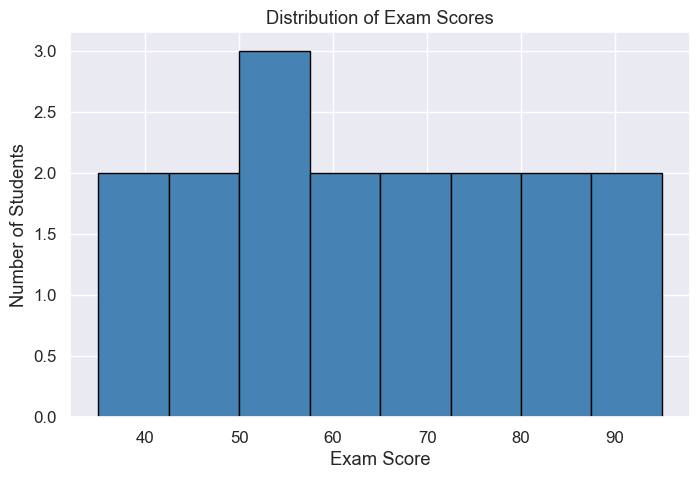

In [11]:
# ==========================================
# Distribution of Exam Scores
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(df["Exam_Score"],
         bins=8,
         color="steelblue",
         edgecolor="black")

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

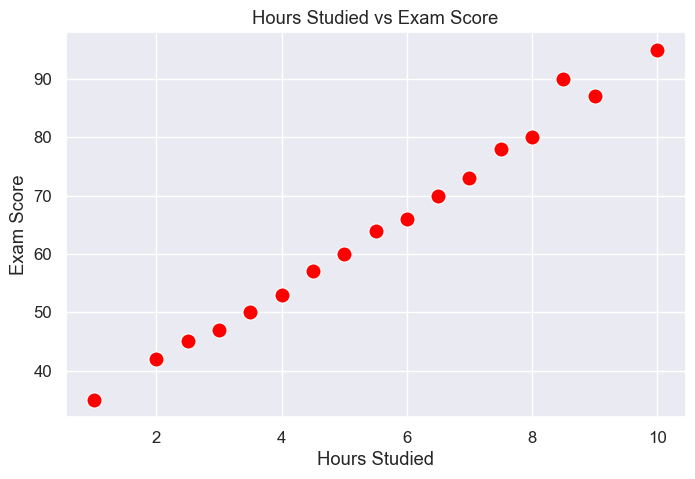

In [12]:
# ==========================================
# Hours Studied vs Exam Score
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Hours_Studied",
    y="Exam_Score",
    data=df,
    s=120,
    color="red"
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

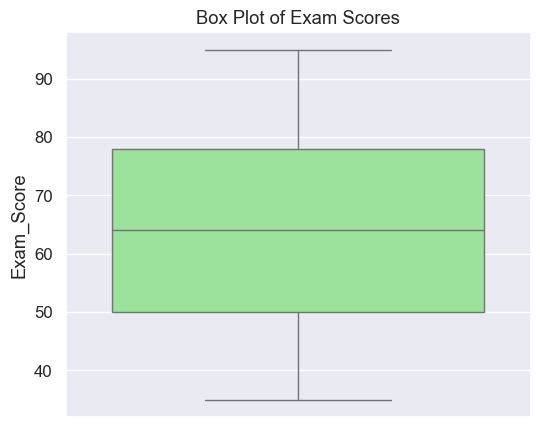

In [13]:
# ==========================================
# Detect Outliers
# ==========================================

plt.figure(figsize=(6,5))

sns.boxplot(y=df["Exam_Score"],
            color="lightgreen")

plt.title("Box Plot of Exam Scores")

plt.show()

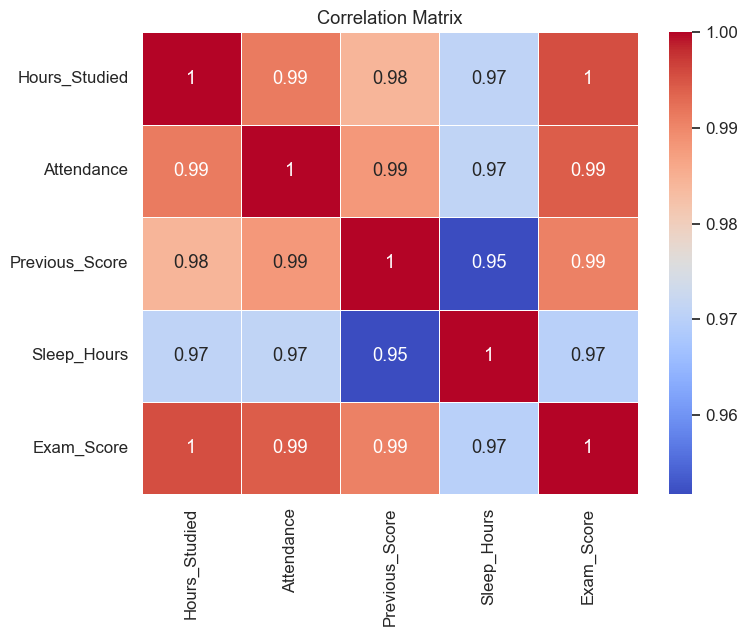

In [14]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

In [15]:
# ==========================================
# Dataset Insights
# ==========================================

print("="*50)
print("DATASET INSIGHTS")
print("="*50)

print(f"Total Students        : {len(df)}")
print(f"Average Study Hours   : {df['Hours_Studied'].mean():.2f}")
print(f"Average Exam Score    : {df['Exam_Score'].mean():.2f}")
print(f"Highest Exam Score    : {df['Exam_Score'].max()}")
print(f"Lowest Exam Score     : {df['Exam_Score'].min()}")

corr = df["Hours_Studied"].corr(df["Exam_Score"])

print(f"\nCorrelation between Study Hours and Exam Score: {corr:.3f}")

if corr > 0.8:
    print("Strong Positive Correlation Found.")
elif corr > 0.5:
    print("Moderate Positive Correlation Found.")
else:
    print("Weak Correlation Found.")

print("\nThe dataset contains no missing values or duplicate records.")
print("The data is clean and ready for Machine Learning.")

DATASET INSIGHTS
Total Students        : 17
Average Study Hours   : 5.50
Average Exam Score    : 64.24
Highest Exam Score    : 95
Lowest Exam Score     : 35

Correlation between Study Hours and Exam Score: 0.996
Strong Positive Correlation Found.

The dataset contains no missing values or duplicate records.
The data is clean and ready for Machine Learning.


# Conclusion

### Key Findings

- The dataset contains **17 student records** with five academic features.
- No missing values or duplicate records were found.
- Students who study more hours generally achieve higher exam scores.
- The correlation matrix indicates a **strong positive relationship** between study hours and exam score.
- The dataset is clean, well-structured, and suitable for building a **Linear Regression** model in the next phase of the project.

